Historical risk-free rates are an essential input into the calibration of economic models. An example of a model that would need historical risk-free rates is where these rates must be deducted from another historic return. For example if the model operates with excess returns. This requires the calculation of historical risk-free curves at different points in history. The purpose of this document is to demonstrate how easy it is to extract such data without external data feeds.

## Scope

This document imports the calibration data from 135 months of EIOPA RFR submissions. For each submission, it takes the EUR base curve without the Volatility Adjustment and interpolates/extrapolates the yield curve of any maturity.

In the second part, two examples are implemented. The first toy example generates the yield curve at a randomly selected date. 

The second toy example generates the implied 1-year forward rate for each curve. This shows how good was the market at guessing the actual forward rate in the future.

## Table of Contents  
 
1. Note on Smith & Wilson algorithm
2. Limitations of the implementation
3. Data requirements
4. External dependencies
5. Smith & Wilson calculation functions
6. Importing data
7. Example 1; Generation of a single risk-free curve
8. Example 2; Generation of all forward rates
9. Conclusion
10. Appendix 1; Calculation of forward rates from the EIOPA yield curve

# Note on Smith & Wilson algorithm

To replicate the calculations, this example uses a modified Smith&Wilson implementation (The original implementation is available on [GitHub](https://github.com/open-source-modelling) at `https://github.com/open-source-modelling`):

-  [Python](https://github.com/open-source-modelling/insurance_python/tree/main/smith_wilson)

-  [Matlab](https://github.com/open-source-modelling/insurance_matlab/tree/main/smith_wilson)

-  [JavaScript](https://github.com/open-source-modelling/insurance_javascript/tree/main/smith_wilson)

# Limitations of the implementation

 - Only one type of yield curves is processed (EUR BASE without Volatility Adjustment)
 - Only 135 months of data are available on the EIOPA website
 - The process, that is left out, is the downloading of every EIOPA submission into a single folder and the use of 2 python functions (One to unzip all files and another to open each Excel file and save the calibration vector Qb and parameters alpha and ufr) 
 - Coupon frequency is assumed to be 1
 - The code was not optimized and the results were not audited as this is just a demonstration project

# Data requirements

This script contains EIOPA risk-free rate calibrations from December 2014 to February 2026. The publication can be found on the [EIOPA RFR website](https://www.eiopa.europa.eu/tools-and-data/risk-free-interest-rate-term-structures_en). The observed maturities `M_Obs` and the calibrated vector `Qb` can be found in a csv file *all_Qb.csv*. These parameters are extracted from for example *EIOPA_RFR_20251231_Term_Structures.xlsx*, sheet *RFR_spot_no_VA*.

The calibration parameters `alpha` and `ufr` can be found in the csv file *all_Qb.csv*. These parameters are extracted from for example  *EIOPA_RFR_20251231_Qb_SW.xlsx*, sheet *RFR_spot_no_VA*.

# External dependencies

This implementation uses five well established Python packages widely used in the financial industry:
 - OS (https://docs.python.org/3/library/os.html)
 - Pandas (https://pandas.pydata.org/docs/)
 - Numpy (https://numpy.org/doc/)
 - Matplotlib (https://matplotlib.org/stable/index.html)
 - Datetime (https://docs.python.org/3/library/datetime.html)

In [115]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import datetime
%matplotlib notebook
%matplotlib inline
pd.options.display.max_rows = 150

# Smith & Wilson calculation functions

In this step, the independent version of the Smith&Wilson algorithm is implemented. To do this, two functions are taken from the publicly available repository and modified to accept the product of `Q*b` instead of the calibration vector `b`.

In [116]:
def SWExtrapolate(M_Target, M_Obs, Qb, ufr, alpha):
# SWEXTRAPOLATE Interpolate or/and extrapolate rates for targeted maturities using a Smith-Wilson algorithm.
# out = SWExtrapolate(M_Target, M_Obs, Qb, ufr, alpha) calculates the rates for maturities specified in M_Target using the calibration vector b.
#
# Arguments: 
#    M_Target = k x 1 ndarray. Each element represents a bond maturity of interest. Ex. M_Target = [[1], [2], [3], [5]]
#    M_Obs =    n x 1 ndarray. Observed bond maturities used for calibrating the calibration vector b. Ex. M_Obs = [[1], [3]]
#    Qb =       n x 1 ndarray. Calibration vector calculated on observed bonds.
#    ufr =      1 x 1 floating number. Representing the ultimate forward rate.
#       Ex. ufr = 0.042
#    alpha =    1 x 1 floating number. Representing the convergence speed parameter alpha. Ex. alpha = 0.05
# 
#
# Returns:
#    k x 1 ndarray. Represents the targeted rates for a zero-coupon bond. Each rate belongs to a targeted zero-coupon bond with a maturity from T_Target. Ex. r = [0.0024; 0.0029; 0.0034; 0.0039]
#
# For more information see https://www.eiopa.europa.eu/sites/default/files/risk_free_interest_rate/12092019-technical_documentation.pdf

    def SWHeart(u, v, alpha):
    # SWHEART Calculate the heart of the Wilson function.
    # H = SWHeart(u, v, alpha) calculates the matrix H (Heart of the Wilson
    # function) for maturities specified by vectors u and v. The formula is
    # taken from the EIOPA technical specifications paragraph 132.
    #
    # Arguments:  
    #    u =     n_1 x 1 vector of maturities. Ex. u = [1; 3]
    #    v =     n_2 x 1 vector of maturities. Ex. v = [1; 2; 3; 5]
    #    alpha = 1 x 1 floating number representing the convergence speed parameter alpha. Ex. alpha = 0.05
    #
    # Returns:
    #    n_1 x n_2 matrix representing the Heart of the Wilson function for selected maturities and parameter alpha. H is calculated as in the paragraph 132 of the EIOPA documentation. 
    #
    # For more information see https://www.eiopa.europa.eu/sites/default/files/risk_free_interest_rate/12092019-technical_documentation.pdf

        u_Mat = np.tile(u, [v.size, 1]).transpose()
        v_Mat = np.tile(v, [u.size, 1])
        return 0.5 * (alpha * (u_Mat + v_Mat) + np.exp(-alpha * (u_Mat + v_Mat)) - alpha * np.absolute(u_Mat-v_Mat) - np.exp(-alpha * np.absolute(u_Mat-v_Mat))); # Heart of the Wilson function from paragraph 132

    H = SWHeart(M_Target, M_Obs, alpha) # Heart of the Wilson function from paragraph 132
    p = np.exp(-np.log(1+ufr)* M_Target) + np.diag(np.exp(-np.log(1+ufr) * M_Target)) @ H @ Qb # Discount pricing function for targeted maturities from paragraph 147
    return p ** (-1/ M_Target) -1 # Convert obtained prices to rates and return prices

# Importing data

Besides the annual yield curve, EIOPA also provides the calibration vectors and other parameters that were used in the generation of the yield curve. They provide the calibration vector, the maturities used, and the extra parameters. These values together uniquely define a yield curve for all maturities. In this section each of these values is imported.

This script uses 2 other csv files. They are saved in the same folder as the Jupyter notebook. The csv files are:

 - *all_Qb.csv*

 - *all_params.csv*

In [117]:
# Get the current working directory
current_dir = os.getcwd()

## Importing calibration vector Qb and maturities

The calibration vectors for every month are saved in a single csv table. The code that extracted all these values is quite simple and can be provided on demand. Email gregor@osmodelling.com.

In [118]:
Qb_path = os.path.join(current_dir,"all_Qb.csv")

In [119]:
all_Qb = pd.read_csv(Qb_path, index_col=0, header=0)

***
<span style=color:black>
    <b>Table of calibration vectors for each month:</b>
</span>
<br>

In [120]:
all_Qb.head()

,20141231,20150131,20150228,20150331,20150430,20150531,20150630,20150731,20150831,20150930,...,20250531,20250630,20250731,20250831,20250930,20251031,20251130,20251231,20260131,20260228
1,-1.939468,-1.299326,-2.121601,-1.982707,-1.705778,-1.462482,-2.105634,-1.376280,-0.992654,-2.221655,...,-7.340896,-7.527116,-5.494647,-10.934610,-3.674961,-9.887615,-17.517586,-0.080928,-9.244373,-20.054483
2,0.897682,0.189297,0.955347,1.036870,0.692480,0.260587,1.367360,0.270575,-0.227070,0.885609,...,7.701123,8.467788,8.637634,11.081177,6.650453,11.979058,25.249358,8.854995,18.911735,19.763417
3,-0.309434,0.992255,-0.366665,-0.333216,1.261338,1.041738,-0.939836,-0.034619,-0.077147,0.201288,...,-1.860756,-0.679369,-3.297036,0.223239,-2.582107,-4.369771,-5.250363,-5.380887,6.250161,-0.046874
4,0.380559,-1.681579,0.610791,0.345546,-2.373877,-1.849785,1.423836,1.096057,2.190649,-0.134304,...,-1.379683,-3.928055,-0.873685,-4.410833,0.011430,-0.152823,-3.301399,1.643257,-15.040031,-8.569125
5,-0.007954,1.371799,-0.505762,-0.107878,1.590187,2.016578,-0.282816,-1.136725,-2.448486,0.536466,...,1.766494,3.676641,1.792586,3.421888,0.179041,0.548897,7.951431,-3.482690,6.749630,11.016758


***

## Importing parameters alpha and ufr

The calibration parameters for every month are saved in a single csv file as a table. The code that extracted all these values from its EIOPA repositories is quite simple and can be provided on demand.

In [121]:
param_path = os.path.join(current_dir,"all_params.csv")

In [122]:
all_params = pd.read_csv(param_path, index_col=0, header=0)

***
<span style=color:black>
    <b>Table of parameters for each month:</b>
</span>
<br>

In [123]:
all_params.head()

,20141231,20150131,20150228,20150331,20150430,20150531,20150630,20150731,20150831,20150930,...,20250531,20250630,20250731,20250831,20250930,20251031,20251130,20251231,20260131,20260228
UFR,4.200000,4.200000,4.200000,4.200000,4.200000,4.200000,4.200000,4.200000,4.200000,4.200000,...,3.300000,3.300000,3.300000,3.300000,3.300000,3.300000,3.30,3.300000,3.30,3.300000
ALPHA,0.129489,0.141014,0.133634,0.138611,0.136078,0.134177,0.130976,0.132822,0.133098,0.131492,...,0.107391,0.093619,0.090782,0.078144,0.082162,0.078955,0.05,0.073632,0.05,0.052922


***

# Example 1; Generation of a single risk-free curve

The first example selects one curve and returns the yield curve for the first 50 years. The code goes step by step for easier understanding of what each step does.

The steps are:

 1) Select the curve

 2) Specify maturities of interest

 3) Extract the calibration

 4) Generate the yield curve

### Selecting the curve

In this section, we select a EIOPA curve out of all 135 options.

In [124]:
loc_selected_curve = 12

In [125]:
all_periods = all_Qb.columns

In [126]:
selected = all_periods[loc_selected_curve]

***
<span style=color:black>
    <b>Selected curve:</b>
</span>
<br>

In [127]:
print(selected)

20151231


***

### Maturities of interest
Vector `M_Target` contains the maturities of interest expressed as fractions of a year. So for example, for a monthly granularity, the maturities are $\frac{1}{12}, \frac{2}{12}, \dots, \frac{12}{12}, \frac{13}{12}, \dots$. For a yearly granularity, the maturities are $1, 2, \dots$.

In [128]:
M_Target =  np.transpose(np.arange(1,50))

***
<span style=color:black>
    <b>Relevant maturities</b>
</span>
<br>
<span style=color:black>   
    Vector of maturities as fractions of a year
</span>

In [129]:
display(M_Target)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

#### Generate coresponding dates

For better readability, we generate the coresponding dates.

In [130]:
year = int(selected[:4])

In [131]:
month = int(selected[4:6])

In [132]:
day = int(selected[6:])

In [133]:
start = datetime.date(year+1, month, day)
end = datetime.date(year+49, month, day)

In [134]:
periods_date = pd.date_range(start = start, end = end, periods = M_Target.shape[0], unit=None)

***
<span style=color:black>
    <b>Selected periods:</b>
</span>
<br>

In [135]:
print(periods_date)

DatetimeIndex(['2016-12-31 00:00:00', '2017-12-31 06:00:00',
               '2018-12-31 12:00:00', '2019-12-31 18:00:00',
               '2020-12-31 00:00:00', '2021-12-31 06:00:00',
               '2022-12-31 12:00:00', '2023-12-31 18:00:00',
               '2024-12-31 00:00:00', '2025-12-31 06:00:00',
               '2026-12-31 12:00:00', '2027-12-31 18:00:00',
               '2028-12-31 00:00:00', '2029-12-31 06:00:00',
               '2030-12-31 12:00:00', '2031-12-31 18:00:00',
               '2032-12-31 00:00:00', '2033-12-31 06:00:00',
               '2034-12-31 12:00:00', '2035-12-31 18:00:00',
               '2036-12-31 00:00:00', '2037-12-31 06:00:00',
               '2038-12-31 12:00:00', '2039-12-31 18:00:00',
               '2040-12-31 00:00:00', '2041-12-31 06:00:00',
               '2042-12-31 12:00:00', '2043-12-31 18:00:00',
               '2044-12-31 00:00:00', '2045-12-31 06:00:00',
               '2046-12-31 12:00:00', '2047-12-31 18:00:00',
               '2048-12-

***

### Extract the calibration

In [136]:
UFR, alpha = all_params.loc[:,selected]

In [137]:
ufr = UFR/100 # Ultimate forward rate ufr represents the rate to which the rate curve will converge as time increases:

***
<span style=color:black>
    <b>Ultimate forward rate</b>
</span>

In [138]:
print(ufr)

0.042


***
<span style=color:black>
    <b>Speed of convergence</b>
</span>


In [139]:
print(alpha)

0.125837


***

In [140]:
Qb_dict = all_Qb.loc[:,selected].to_dict()

This vector contains two elements necessary to calibrate the SW algorithm. The maturities and the values. Each is saved in a separate numpy array.

In [141]:
Qb = np.array(list(Qb_dict.values()))

***
<span style=color:black>
    <b>Calibration vector</b>
</span>
<br>
<span style=color:black>   
    Vector <b>Qb</b> provided as input
</span>

In [142]:
display(Qb)

array([-2.7818207 ,  0.69215534,  2.01848628, -2.47342924,  2.58292883,
       -1.57270535,  0.76023623,  0.32135971, -0.00574162, -0.82353029,
        0.00806975,  1.04170732, -0.00337368, -0.00323769, -1.520044  ,
        0.01589241,  0.01525184,  0.01463708,  0.0140471 ,  0.93393039])

***

In [143]:
M_Obs = np.transpose(np.array(list(Qb_dict.keys())))

***
<span style=color:black>
    <b>Maturities used in the calibration</b>
</span>
<br>
<span style=color:black>   
    Vector <b>M_Obs</b> provided as input
</span>

In [144]:
display(M_Obs)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

### Generate the yield curve

A single function is called to generate the desired results.

In [145]:
r_Target = SWExtrapolate(M_Target,M_Obs, Qb, ufr, alpha)
r_Target = pd.DataFrame(r_Target,columns=['Recalculated rates'], index = M_Target)

***
<span style=color:black>
    <b>Example 1, generated yield curve</b>
</span>
<br>
<span style=color:black>   
    The yield curve for the first 50 years for the calibration at December 2015:
</span>

In [146]:
r_Target.head()

,Recalculated rates
1,-0.001570
2,-0.001290
3,-0.000375
4,0.000965
5,0.002321


***
<span style=color:black>
    <b>Plot of the recalculated yield curve</b>
</span>


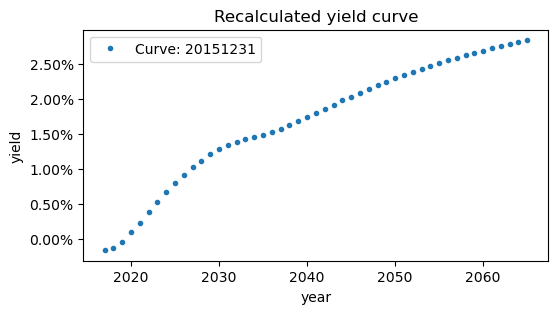

In [147]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(periods_date, r_Target.values*100, color='tab:blue',label="Curve: "+str(selected), marker='.', linestyle='')

ax1.set_ylabel("yield")
ax1.set_title('Recalculated yield curve')
ax1.set_xlabel("year")
ax1.legend()
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
fig.set_figwidth(6)
fig.set_figheight(3)
plt.show()

***

# Example 2; Generation of all forward rates

For the second example, we tried using a more realistic question. This toy model produces the yield curve as reported by EIOPA every month for the past 135 months and based on that calculates the 1-year implied forward rate. It then plots them sequentially on the same time axis. This can show an audience in a visual way how good is the EIOPA methodology in predicting the future forward rates. The additional steps for calculating the forward rates from the yield curve are shown at the end of the document in the appendix.


For each curve, the plot will contain only the first 10 years of forward rates:

In [148]:
l_proj = 10

In [149]:
M_Target = np.transpose(np.arange(1,l_proj+1))

***
<span style=color:black>
    <b>Maturities of interest:</b>
</span>
<br>

In [150]:
display(M_Target)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

***
<span style=color:black>
    <b>Forward rates through time</b>
</span>


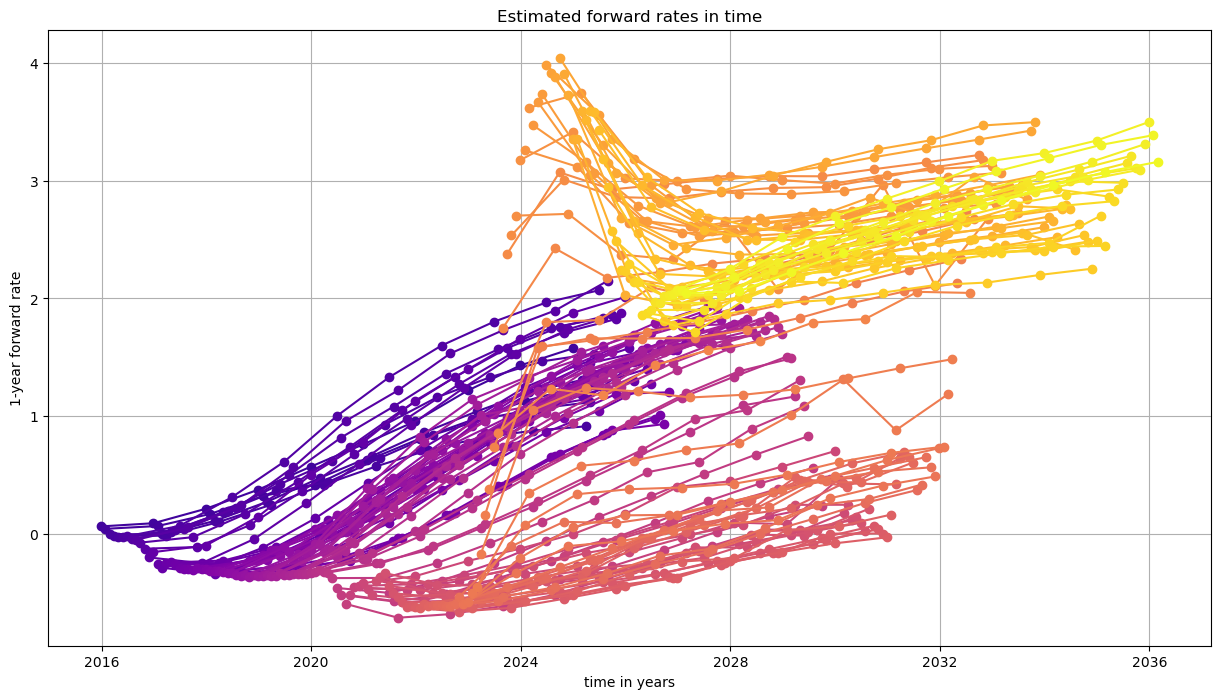

In [151]:
cmap = plt.get_cmap('plasma')  # You can change this to any colormap

plt.figure(figsize=(15, 8))

for loc_selected_curve in range(all_periods.shape[0]):
    
    all_periods = all_Qb.columns
    selected = all_periods[loc_selected_curve]
    year = int(selected[:4])
    month = int(selected[4:6])
    day = int(selected[6:])
    start = datetime.date(year+1, month, 28)
    end = datetime.date(year+l_proj, month, 28)
    periods_date = pd.date_range(start = start, end =end, periods = l_proj, unit=None)
    UFR, alpha = all_params.loc[:,selected]
    Qb_dict = all_Qb.loc[:,selected].to_dict()
    Qb = np.array(list(Qb_dict.values()))
    M_Obs = np.transpose(np.array(list(Qb_dict.keys())))
    
    ufr = UFR/100
    
    r_Target = SWExtrapolate(M_Target,M_Obs, Qb, ufr, alpha)
    r_Target = pd.DataFrame(r_Target,columns=['Recalculated rates'], index = M_Target)

    # Separate funtion to compute FWDs from yields
    ZCB_price = (1+r_Target.values) ** -M_Target[:,np.newaxis]

    ZCB_price_2 = np.append(1,ZCB_price)

    fwd_rates_input = ZCB_price_2[:-1] / ZCB_price_2[1:]-1

    fwd_rates_df = pd.DataFrame(data = fwd_rates_input, index = M_Target, columns=["FORWARD_RATE"])

    x = periods_date
    y = fwd_rates_df.values*100
  
    color_intensity = 0.1 + (0.9 * (loc_selected_curve / all_periods.shape[0]))
    color = cmap(color_intensity)
    
    plt.plot(x, y, '-o', color=color,label=str(selected))
    
plt.xlabel('time in years')
plt.ylabel('1-year forward rate')
plt.title('Estimated forward rates in time')
plt.grid(True)
plt.show()

***

# Conclusion

The above notebook shows how to gather a large number of historic EIOPA risk-free rate curves for further processing. To demonstrate the necessary steps, the script shows two separate examples. The first one generates a randomly chosen yield curve for desired maturities. This example is longer and shows intermediate steps. 

The second example shows how one can use all the curves to answer a larger question of historical accuracy of the EIOPA methodology.

# Appendix 1; Calculation of forward rates from the EIOPA yield curve

$$
ZCB(0,t) = \frac{1}{(1+y^{EIOPA}_t)^t}
$$

Forward rates can be calculated from the equation:
$$
1 + fw^{EIOPA, m}_t = \frac{ZCB(0,t)}{ZCB(0,t+1)}
$$

therefore:

$$
fw^{EIOPA, m}_t = \frac{ZCB(0,t)}{ZCB(0,t+1)}-1
$$

where:

 - $t \dots$ is the maturity of interest (in months)

 - $y^{EIOPA}_t$ is the calculated yield for the maturity $t$, retrieved from the EIOPA calibration

 - $ZCB(0,t) \dots$ is the price of a zero coupon bond, issued at time 0 and maturing at time $t$

 - $fw^{EIOPA, m}_t \dots$ implied monthly forward return of the EIOPA between times $t$ and $t+1$